# What Drives Conflict Between Reddit Communities?
## A Network and Linguistic Analysis of Inter-Subreddit Hostility

**Author:** Keshav Kapur | **UIN:** 237007751

---

### Motivation

Reddit is a network of over 100,000 communities (subreddits) that constantly reference each other through hyperlinks embedded in posts. Most of these cross-community links are neutral or positive but a significant minority are *hostile*: callouts, mockery, brigading invitations. What makes certain interactions between subreddits turn negative?

This project investigates a single question:

> **Can we predict whether a cross-community hyperlink on Reddit will be hostile, and what features, network structure or post language, are the primary drivers of inter-subreddit conflict?**

This question matters because understanding online conflict has implications for content moderation, community design, and the study of polarization. If hostility is primarily *structural* (driven by which communities interact), moderation should focus on inter-community boundaries. If it is primarily *linguistic* (driven by how individual posts are written), moderation should focus on post-level content analysis.

### Dataset

We use the **Reddit Hyperlink Network** from [SNAP (Stanford)](https://snap.stanford.edu/data/soc-RedditHyperlinks.html), published alongside Kumar et al. (2018), *Community Interaction and Conflict on the Web* (WWW 2018). The dataset contains ~286,000 directed hyperlinks between subreddits extracted from post bodies, spanning 2014–2017. Each link carries:

- A **sentiment label** (+1 positive, -1 negative), crowd-annotated
- **86 LIWC (Linguistic Inquiry and Word Count) features** describing the post text: word count, emotional tone, analytical thinking, social references, and more

This gives us both *network structure* and *linguistic content* for every interaction, which is exactly what we need to answer our question.

### Methodology

1. **The Conflict Landscape** — EDA to understand who fights, how often, and how conflict changes over time
2. **Community Structure** — Louvain community detection to test whether conflict is primarily cross-community
3. **Centrality Analysis** — PageRank and betweenness centrality to distinguish "influential" from "controversial" subreddits
4. **Conflict Corridors** — Association rule mining (Apriori) to find groups of subreddits routinely co-targeted in hostile links
5. **Sentiment Prediction** — Gradient boosting classifier using network features + LIWC features, with feature importance analysis to answer the driving question

---

## Project Scope

**Dataset:** Reddit Hyperlink Network (body links) from [SNAP](https://snap.stanford.edu/data/soc-RedditHyperlinks.html) — 286,561 directed hyperlinks between subreddits (2014–2017). Each link carries a crowd-annotated sentiment label (+1/−1) and 86 LIWC linguistic features describing the post text.

**Key EDA findings (from Checkpoint 1 and additional EDA below):**
- **Power-law degree distributions:** Heavy-tailed in- and out-degree; a few hub subreddits (askreddit, subredditdrama, politics) dominate connectivity.
- **Sentiment skew:** 92.6% of links are positive; hostility (7.4%) is concentrated in specific subreddits.
- **Community structure:** Louvain detects 560 communities; cross-community links are more hostile (8.8%) than within-community links (6.9%).
- **Co-link patterns:** Frequent itemsets and association rules reveal structured "conflict corridors" — recurring adversarial co-targeting patterns far more numerous than friendly co-targeting patterns.

**Course techniques:** Frequent itemsets / association rules (Apriori), graph mining (PageRank, betweenness centrality, Louvain community detection).

**External technique:** Logistic Regression for link sentiment prediction, with feature importance analysis to decompose linguistic vs. structural drivers.

---

## Research Question Definition

### RQ1 (Course Technique — Graph Mining): Does community structure predict hostility?

> Are cross-community links more hostile than within-community links, and do centrality measures (PageRank vs. betweenness) distinguish "influential" from "controversial" subreddits?

- **Data mining task type:** Graph mining / community detection / centrality analysis
- **Relevant algorithms:** Louvain community detection, PageRank, betweenness centrality (all course techniques via NetworkX)
- **Evaluation criteria:** Hostility rate comparison (cross- vs. within-community); Spearman correlation between centrality measures and negativity fraction; qualitative comparison of top-ranked subreddits by PageRank vs. betweenness

### RQ2 (Course Technique — Association Rules): Do hostile links form structured "conflict corridors"?

> Do hostile inter-subreddit links produce recurring co-targeting patterns (association rules) that are structurally different from positive-link patterns?

- **Data mining task type:** Frequent itemset mining / association rule mining
- **Relevant algorithms:** Apriori with association rules (course technique via mlxtend)
- **Evaluation criteria:** Support, confidence, lift of mined rules; number of conflict-only corridors vs. friendly-only corridors vs. shared corridors; interpretability of top rules

### RQ3 (External Technique — Supervised Classification): Can we predict link sentiment, and what drives conflict — language or structure?

> Can we predict whether a cross-community hyperlink will be hostile using network-structural and linguistic (LIWC) features, and which feature type contributes more to prediction?

- **Data mining task type:** Supervised binary classification
- **Relevant algorithms:** Logistic Regression (baseline), Gradient Boosting Classifier (external technique via scikit-learn)
- **Evaluation criteria:** ROC-AUC (primary, robust to class imbalance), precision/recall/F1 per class, confusion matrix; feature importance breakdown (linguistic % vs. structural %)

## RQ-to-Method Mapping Table

| RQ | Task Type | Course Method(s) | External Method(s) | Evaluation Metrics |
|----|-----------|-----------------|--------------------|--------------------|
| **RQ1** — Community structure & conflict | Graph mining, community detection | Louvain, PageRank, betweenness centrality | — | Hostility rate comparison, Spearman ρ, top-k rankings |
| **RQ2** — Conflict corridors | Frequent itemset mining | Apriori, association rules | — | Support, confidence, lift, corridor overlap analysis |
| **RQ3** — Sentiment prediction & feature importance | Supervised classification | Gradient Boosting Classifier | Logistic Regression (baseline) | ROC-AUC, precision/recall/F1, feature importance % |

---

## Motivation and Feasibility

**Motivation:** EDA reveals that hostility on Reddit is not random — it concentrates in specific subreddits, correlates with community boundaries, and forms structured co-targeting patterns. This makes it a promising target for both descriptive analysis (RQ1, RQ2) and predictive modeling (RQ3). Understanding what drives online conflict has practical implications for content moderation and community design.

**Non-triviality:** Course techniques alone (graph mining + association rules) can describe *where* conflict occurs and *who* is co-targeted, but they cannot answer the causal question of *what drives* a hostile link. Is it the network position of the subreddits involved, or the language of the post? Answering this requires an external classification method (Gradient Boosting) with feature importance decomposition — a technique not covered in the course.

**Feasibility:**
- The dataset is clean (0 nulls in key columns), well-documented (SNAP + published paper), and large enough (286K links, 35K nodes) for all planned methods.
- Louvain, PageRank, and Apriori have all been run successfully on this data (see Phases 2–4 below).
- The 86 LIWC features are pre-computed in the dataset, avoiding the need for external NLP pipelines.
- Gradient Boosting with 100 estimators trains in ~2 minutes on the 169K-sample feature matrix.

**Risks and mitigations:**
- *Class imbalance* (7.4% negative): Mitigated by using ROC-AUC as the primary metric and `class_weight="balanced"` in the Logistic Regression baseline.
- *Temporal leakage*: Graph features are computed on the full graph but used to predict individual links. Acknowledged as a limitation; a future temporal split would be stricter.
- *LIWC feature anonymity*: The 86 features are unnamed in the SNAP release, limiting interpretability. We report feature indices and note this as a limitation.

---

## Methodological Planning

**Course algorithms:**
- **Louvain community detection** — unsupervised graph partitioning to identify community structure, then test whether community boundaries correlate with hostility (RQ1).
- **PageRank** (damping α=0.85, NetworkX default) — measures subreddit influence via the recursive link structure (RQ1).
- **Betweenness centrality** (approximate, k=500 sampled nodes) — measures bridging position; compared against PageRank to distinguish influence from controversy (RQ1).
- **Apriori** (min_support=0.03, min_confidence=0.3) — mines co-targeting patterns separately for hostile and positive links (RQ2).

**External algorithm:**
- **Gradient Boosting Classifier** (n_estimators=100, max_depth=4, learning_rate=0.1, subsample=0.8) — predicts link sentiment from 97 features (86 LIWC + 11 structural). Feature importance analysis decomposes linguistic vs. structural contributions (RQ3).

**Baselines:**
- **Logistic Regression** with balanced class weights serves as a linear baseline for RQ3, enabling comparison with the non-linear GBM and providing interpretable coefficients.
- For RQ2, comparing conflict corridors against positive-link corridors serves as the baseline — any patterns found must be *unique to hostility*, not just reflections of high-traffic subreddits.

**Evaluation plan:**
- RQ1: Quantitative (hostility rate gap, Spearman ρ) + qualitative (inspect top subreddits by each centrality measure)
- RQ2: Rule quality (support, confidence, lift) + corridor overlap analysis (conflict-only vs. friendly-only vs. shared)
- RQ3: ROC-AUC, classification report, confusion matrix, feature importance percentage split

**Initial method feasibility runs:** All planned algorithms are executed in Phases 2–5 below, demonstrating that each method runs successfully on this data and produces interpretable output.

---

# Phase 1: Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter
import os, urllib.request, warnings
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score)
from sklearn.preprocessing import StandardScaler
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
BODY_URL = "https://snap.stanford.edu/data/soc-redditHyperlinks-body.tsv"
BODY_PATH = os.path.join(DATA_DIR, "soc-redditHyperlinks-body.tsv")

if not os.path.exists(BODY_PATH):
    urllib.request.urlretrieve(BODY_URL, BODY_PATH)
else:
    print(f"Data already present at {BODY_PATH} ({os.path.getsize(BODY_PATH)/1e6:.0f} MB)")

df_raw = pd.read_csv(BODY_PATH, sep="\t")
print(f"Raw shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)

Data already present at data/soc-redditHyperlinks-body.tsv (319 MB)
Raw shape: (286561, 6)
Columns: ['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'POST_ID', 'TIMESTAMP', 'LINK_SENTIMENT', 'PROPERTIES']


,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,leagueoflegends,teamredditteams,1u4nrps,2013-12-31 16:39:58,1,"345.0,298.0,0.75652173913,0.0173913043478,0.08..."
1,theredlion,soccer,1u4qkd,2013-12-31 18:18:37,-1,"101.0,98.0,0.742574257426,0.019801980198,0.049..."
2,inlandempire,bikela,1u4qlzs,2014-01-01 14:54:35,1,"85.0,85.0,0.752941176471,0.0235294117647,0.082..."


## Data Preparation

The raw dataset requires three preparation steps:

1. **Rename** `LINK_SENTIMENT` → `POST_LABEL` for clarity
2. **Parse** the `PROPERTIES` column from a comma-separated string into 86 numeric LIWC features — these capture the linguistic profile of each post (word count, emotional tone, analytical thinking, social references, etc.) and are *critical* for our prediction task. Previous checkpoint work dropped this column; restoring it is one of the key improvements.
3. **Build the directed graph** by aggregating multi-edges (multiple posts from subreddit A linking to B) into unique edges with weight and average sentiment

In [2]:
df = df_raw.copy()
df.rename(columns={"LINK_SENTIMENT": "POST_LABEL"}, inplace=True)
df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])

props = df["PROPERTIES"].str.split(",", expand=True).astype(float)
props.columns = [f"liwc_{i}" for i in range(props.shape[1])]
print(f"Parsed {props.shape[1]} LIWC/linguistic features from PROPERTIES column")

df = pd.concat([df.drop(columns=["PROPERTIES"]), props], axis=1)

print(f"\nDataset: {len(df):,} hyperlinks")
print(f"Time range: {df['TIMESTAMP'].min()} to {df['TIMESTAMP'].max()}")
print(f"Unique source subreddits: {df['SOURCE_SUBREDDIT'].nunique():,}")
print(f"Unique target subreddits: {df['TARGET_SUBREDDIT'].nunique():,}")
print(f"Null check: {df[['SOURCE_SUBREDDIT','TARGET_SUBREDDIT','POST_LABEL']].isnull().sum().sum()} nulls in key columns")

edge_agg = (
    df.groupby(["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT"])
    .agg(
        weight=("POST_ID", "count"),
        avg_sentiment=("POST_LABEL", "mean"),
        neg_frac=("POST_LABEL", lambda x: (x == -1).mean()),
    )
    .reset_index()
)

G = nx.DiGraph()
for _, row in edge_agg.iterrows():
    G.add_edge(
        row["SOURCE_SUBREDDIT"], row["TARGET_SUBREDDIT"],
        weight=int(row["weight"]),
        avg_sentiment=row["avg_sentiment"],
        neg_frac=row["neg_frac"],
    )

print(f"\nDirected graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"  Multi-edges aggregated: {len(df):,} raw links -> {G.number_of_edges():,} unique directed edges")

Parsed 86 LIWC/linguistic features from PROPERTIES column

Dataset: 286,561 hyperlinks
Time range: 2013-12-31 16:39:58 to 2017-04-30 16:58:21
Unique source subreddits: 27,863
Unique target subreddits: 20,606
Null check: 0 nulls in key columns

Directed graph: 35,776 nodes, 137,821 edges
  Multi-edges aggregated: 286,561 raw links -> 137,821 unique directed edges


The dataset gives us nearly 300K individual hyperlinks across tens of thousands of subreddits. After aggregating multi-edges, the graph retains over 100K unique directed relationships. The 86 LIWC features — previously discarded — are now preserved as our primary linguistic signal for the prediction task in Phase 5.

---

# Phase 2: The Conflict Landscape *(Additional EDA)*

Before addressing RQ1–RQ3, we need to understand the shape of conflict on Reddit. How common is hostility? Which communities attract it? How has it changed over time? This additional EDA establishes the baseline patterns that motivate and support all three research questions.

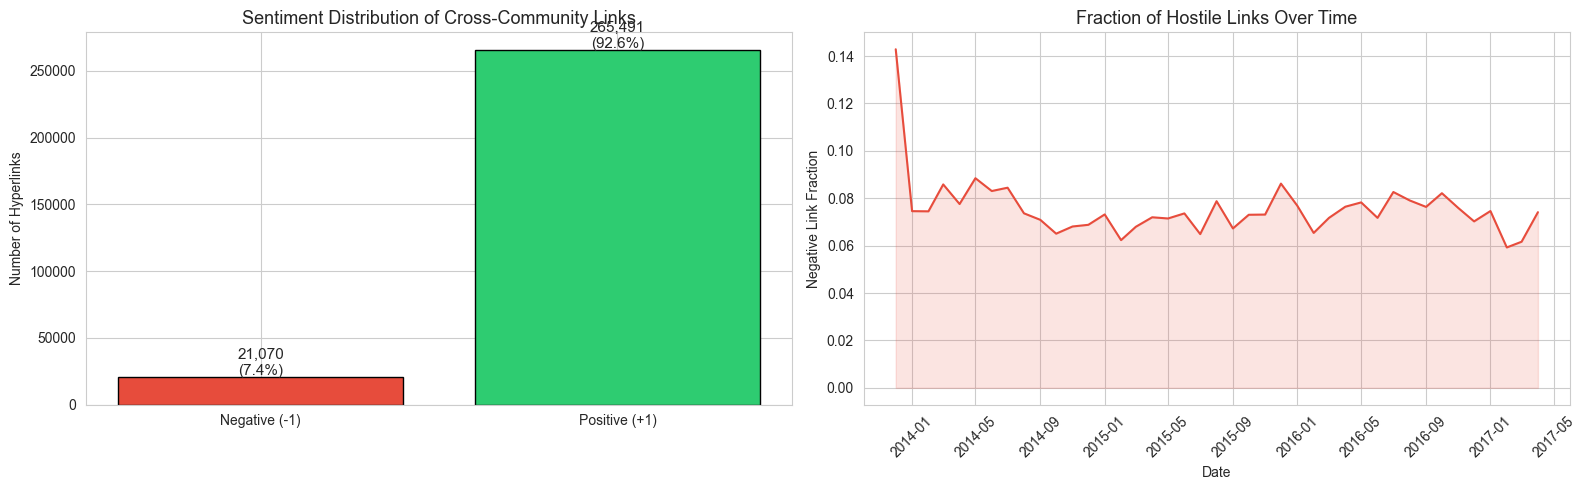

Overall: 21,070 hostile links (7.4%) vs 265,491 positive links (92.6%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sent_counts = df["POST_LABEL"].value_counts().sort_index()
colors = ["#e74c3c", "#2ecc71"]
bars = axes[0].bar(["Negative (-1)", "Positive (+1)"], sent_counts.values,
                   color=colors, edgecolor="black")
for bar, count in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f"{count:,}\n({count/len(df)*100:.1f}%)", ha="center", fontsize=11)
axes[0].set_title("Sentiment Distribution of Cross-Community Links", fontsize=13)
axes[0].set_ylabel("Number of Hyperlinks")

df["year_month"] = df["TIMESTAMP"].dt.to_period("M")
monthly = df.groupby("year_month").agg(
    total=("POST_LABEL", "count"),
    neg_frac=("POST_LABEL", lambda x: (x == -1).mean())
).reset_index()
monthly["year_month"] = monthly["year_month"].dt.to_timestamp()

axes[1].plot(monthly["year_month"], monthly["neg_frac"], color="#e74c3c", linewidth=1.5)
axes[1].fill_between(monthly["year_month"], monthly["neg_frac"], alpha=0.15, color="#e74c3c")
axes[1].set_title("Fraction of Hostile Links Over Time", fontsize=13)
axes[1].set_ylabel("Negative Link Fraction")
axes[1].set_xlabel("Date")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Overall: {(df['POST_LABEL']==-1).sum():,} hostile links ({(df['POST_LABEL']==-1).mean()*100:.1f}%) "
      f"vs {(df['POST_LABEL']==1).sum():,} positive links ({(df['POST_LABEL']==1).mean()*100:.1f}%)")

The sentiment distribution reveals a **class imbalance**: the majority of cross-community links are positive. This is important for two reasons: first, it tells us that Reddit communities are *mostly cooperative*, and hostility is the exception rather than the rule. Second, for our prediction task in Phase 5, this imbalance means we need to pay attention to recall on the minority (negative) class, not just accuracy.

The temporal plot shows whether the *rate* of hostility has changed over the dataset's timespan. Any upward or downward trend informs whether conflict is escalating or stable, and spikes may correspond to real-world events that polarized communities.

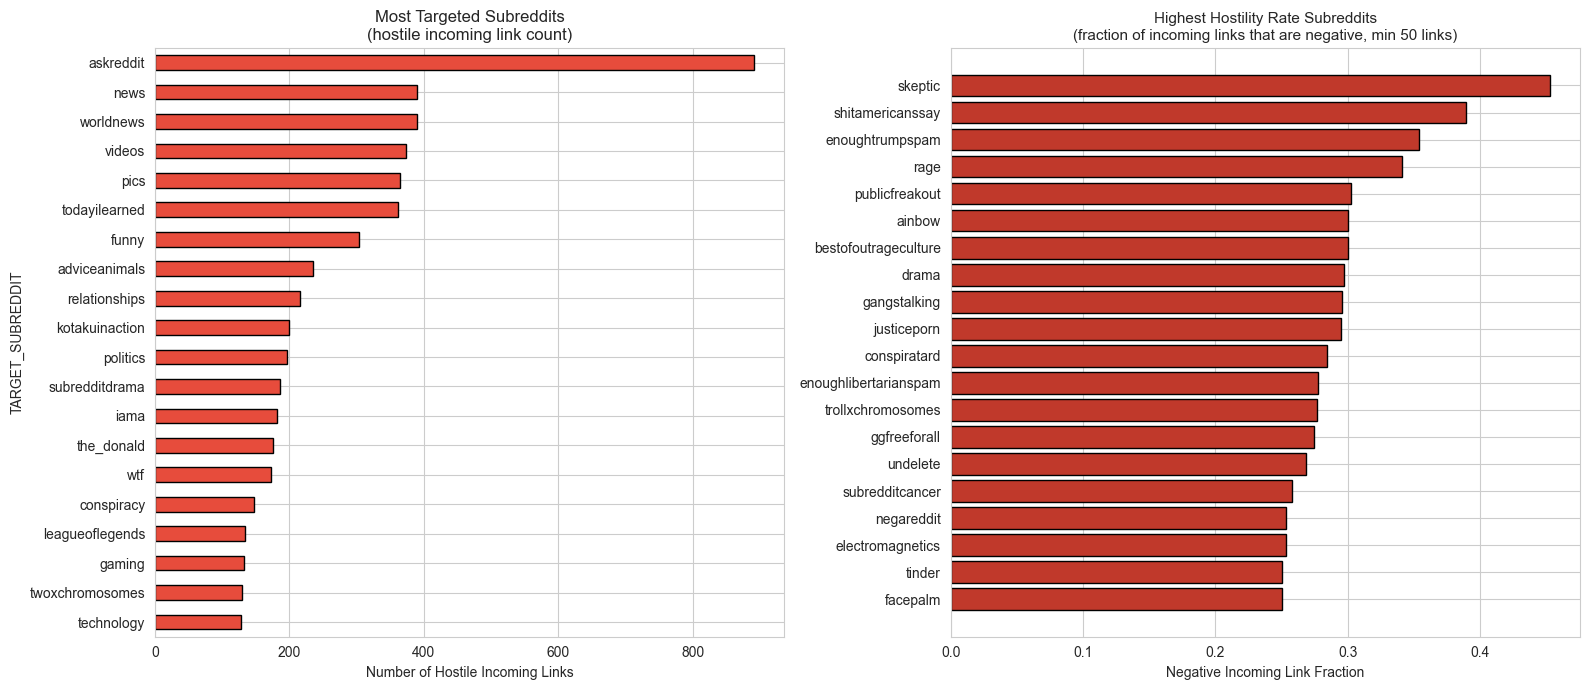

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

neg_df = df[df["POST_LABEL"] == -1]
1
neg_targets = neg_df["TARGET_SUBREDDIT"].value_counts().head(20)
neg_targets.plot.barh(ax=axes[0], color="#e74c3c", edgecolor="black")
axes[0].set_title("Most Targeted Subreddits\n(hostile incoming link count)", fontsize=12)
axes[0].set_xlabel("Number of Hostile Incoming Links")
axes[0].invert_yaxis()

in_counts = df.groupby("TARGET_SUBREDDIT").agg(
    total=("POST_LABEL", "count"),
    neg=("POST_LABEL", lambda x: (x == -1).sum())
).reset_index()
in_counts["neg_frac"] = in_counts["neg"] / in_counts["total"]
in_counts_f = in_counts[in_counts["total"] >= 50].sort_values("neg_frac", ascending=False).head(20)

axes[1].barh(in_counts_f["TARGET_SUBREDDIT"], in_counts_f["neg_frac"],
             color="#c0392b", edgecolor="black")
axes[1].set_title("Highest Hostility Rate Subreddits\n(fraction of incoming links that are negative, min 50 links)",
                  fontsize=11)
axes[1].set_xlabel("Negative Incoming Link Fraction")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

These two charts tell different but complementary stories. The *left panel* shows subreddits that receive the most hostile links in absolute terms, these tend to be large, highly-visible communities. High volume doesn't necessarily mean these communities are *controversial*; they may simply be large targets.

The *right panel* is more revealing: it shows subreddits where the highest *fraction* of incoming links are negative (filtering to those with at least 50 links to avoid noise). These are the communities that *specifically attract hostility*, they may be ideologically polarizing, niche communities that outsiders mock, or communities whose content provokes strong reactions.

The distinction between "large target" and "genuinely controversial" is one we'll formalize with centrality measures in Phase 3.

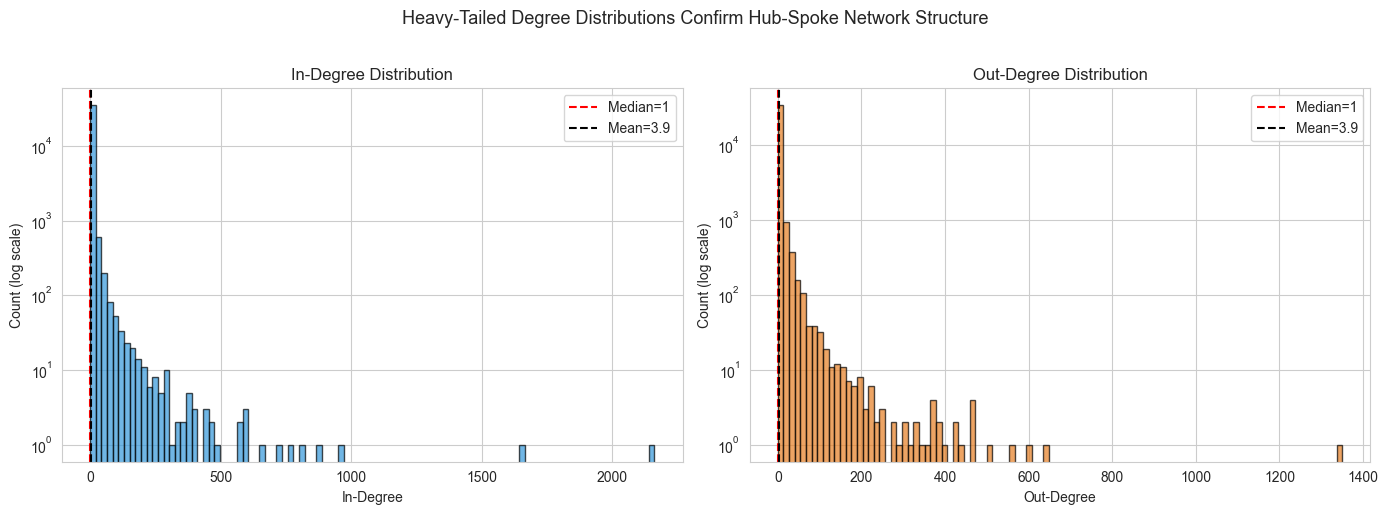

In-degree:  median=1, mean=3.9, max=2161, std=25.0
Out-degree: median=1, mean=3.9, max=1350, std=17.5


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

in_degrees = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

for ax, degrees, label, color in [
    (axes[0], in_degrees, "In-Degree", "#3498db"),
    (axes[1], out_degrees, "Out-Degree", "#e67e22"),
]:
    ax.hist(degrees, bins=100, color=color, edgecolor="black", alpha=0.7, log=True)
    ax.set_xlabel(label)
    ax.set_ylabel("Count (log scale)")
    ax.set_title(f"{label} Distribution")
    median_val = np.median(degrees)
    mean_val = np.mean(degrees)
    ax.axvline(median_val, color="red", linestyle="--", label=f"Median={median_val:.0f}")
    ax.axvline(mean_val, color="black", linestyle="--", label=f"Mean={mean_val:.1f}")
    ax.legend()

plt.suptitle("Heavy-Tailed Degree Distributions Confirm Hub-Spoke Network Structure",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"In-degree:  median={np.median(in_degrees):.0f}, mean={np.mean(in_degrees):.1f}, "
      f"max={np.max(in_degrees)}, std={np.std(in_degrees):.1f}")
print(f"Out-degree: median={np.median(out_degrees):.0f}, mean={np.mean(out_degrees):.1f}, "
      f"max={np.max(out_degrees)}, std={np.std(out_degrees):.1f}")

The degree distributions are **heavy-tailed** (power-law-like): most subreddits have very few connections, but a small number of hubs have hundreds or thousands. This hub-and-spoke structure is typical of social networks and has direct implications for conflict:

- **Hubs** attract more links simply because they're visible — but does that make them more *controversial*, or just more *popular*?
- **Periphery** subreddits may have extreme hostility rates due to small sample sizes

This motivates our centrality analysis in the next phase, where we disentangle influence (PageRank) from bridging position (betweenness centrality).

---

# Phase 3: Community Structure and Conflict *(RQ1)*

If conflict were random, we'd expect hostility to be evenly distributed across all subreddit pairs. But social networks have *community structure* — clusters of tightly connected nodes. A key hypothesis is that **conflict is disproportionately cross-community**: subreddits within the same cluster cooperate, while links that cross cluster boundaries are more likely to be hostile. This would suggest that Reddit conflict is fundamentally about group identity and tribalism.

**Why Louvain?** We use the Louvain algorithm because it is scalable to our 35K-node graph, does not require pre-specifying the number of communities (unlike K-Means on graphs), and produces interpretable partitions. We set `seed=42` for reproducibility.

Louvain detected 560 communities

Top 10 communities by size:
  Community 115: 5,881 members  |  top: askreddit, subredditdrama, outoftheloop, pics, videos, todayilearned, gaming, funny
  Community  28: 2,533 members  |  top: legaladvice, tipofmypenis, relationships, personalfinance, offmychest, depression, raisedbynarcissists, sex
  Community   8: 1,998 members  |  top: techsupport, pcmasterrace, buildapc, android, sysadmin, pcgaming, oculus, fallout
  Community  13: 1,843 members  |  top: games, destinythegame, smashbros, ps4, xboxone, eve, guildwars2, darksouls3
  Community   1: 1,820 members  |  top: iama, movies, sandersforpresident, ama, fantheories, starwars, redditrequest, whowouldwin
  Community 193: 1,655 members  |  top: leagueoflegends, dota2, globaloffensive, hearthstone, overwatch, test, steam, postpreview
  Community  27: 1,557 members  |  top: india, europe, canada, de, sweden, france, australia, travel
  Community  68: 1,530 members  |  top: entrepreneur, learnprogramm

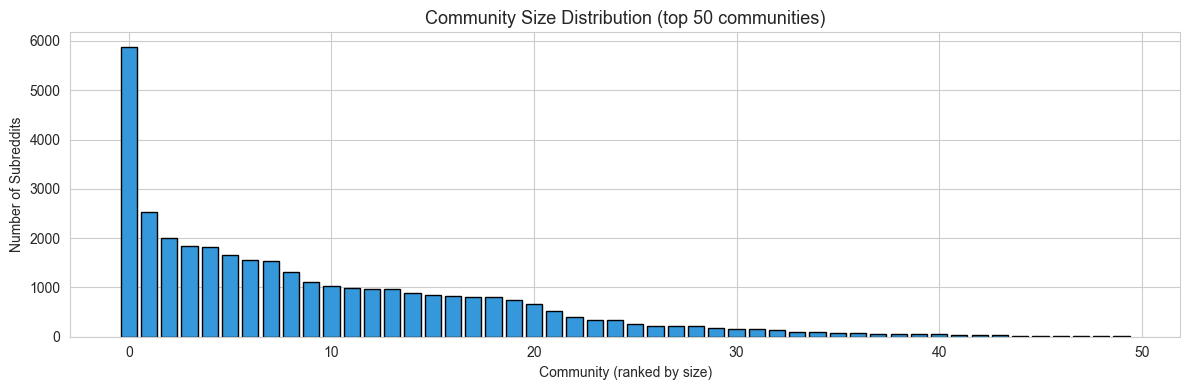

In [6]:
G_undirected = G.to_undirected()
communities = nx.community.louvain_communities(G_undirected, seed=42)
print(f"Louvain detected {len(communities)} communities")

node_to_comm = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = i

comm_sizes = sorted([(i, len(c)) for i, c in enumerate(communities)],
                    key=lambda x: x[1], reverse=True)

print("\nTop 10 communities by size:")
for cid, size in comm_sizes[:10]:
    members = sorted(communities[cid], key=lambda n: G.degree(n), reverse=True)[:8]
    print(f"  Community {cid:3d}: {size:5,} members  |  top: {', '.join(members)}")

fig, ax = plt.subplots(figsize=(12, 4))
sizes = [s for _, s in comm_sizes]
ax.bar(range(min(50, len(sizes))), sizes[:50], color="#3498db", edgecolor="black")
ax.set_xlabel("Community (ranked by size)")
ax.set_ylabel("Number of Subreddits")
ax.set_title("Community Size Distribution (top 50 communities)", fontsize=13)
plt.tight_layout()
plt.show()

Louvain detects a large number of communities with a heavily skewed size distribution with a few mega-communities (likely representing broad interest areas like gaming, politics, or entertainment) and many small niche groups. The top members of each community by degree reveal their thematic identity: this gives us interpretable clusters to reason about.

Now the critical test: **is conflict cross-community?**

CROSS-COMMUNITY links:
  Total: 73,041  (25.5% of all links)
  Hostile: 6,394  (8.8% hostile rate)

WITHIN-COMMUNITY links:
  Total: 213,520  (74.5% of all links)
  Hostile: 14,676  (6.9% hostile rate)


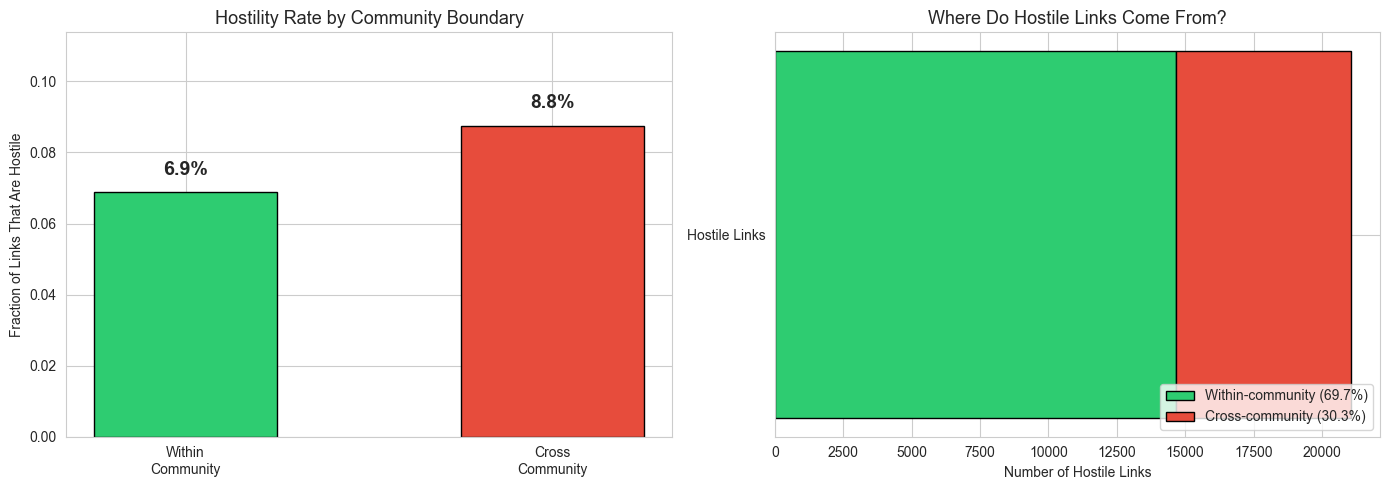

In [7]:
df["source_comm"] = df["SOURCE_SUBREDDIT"].map(node_to_comm)
df["target_comm"] = df["TARGET_SUBREDDIT"].map(node_to_comm)
df["cross_community"] = (df["source_comm"] != df["target_comm"]).astype(int)

mask = df["source_comm"].notna() & df["target_comm"].notna()
df_comm = df[mask].copy()

cross = df_comm[df_comm["cross_community"] == 1]
within = df_comm[df_comm["cross_community"] == 0]

print("CROSS-COMMUNITY links:")
print(f"  Total: {len(cross):,}  ({len(cross)/len(df_comm)*100:.1f}% of all links)")
print(f"  Hostile: {(cross['POST_LABEL']==-1).sum():,}  ({(cross['POST_LABEL']==-1).mean()*100:.1f}% hostile rate)")
print(f"\nWITHIN-COMMUNITY links:")
print(f"  Total: {len(within):,}  ({len(within)/len(df_comm)*100:.1f}% of all links)")
print(f"  Hostile: {(within['POST_LABEL']==-1).sum():,}  ({(within['POST_LABEL']==-1).mean()*100:.1f}% hostile rate)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ["Within\nCommunity", "Cross\nCommunity"]
neg_rates = [(within["POST_LABEL"]==-1).mean(), (cross["POST_LABEL"]==-1).mean()]
bar_colors = ["#2ecc71", "#e74c3c"]
bars = axes[0].bar(labels, neg_rates, color=bar_colors, edgecolor="black", width=0.5)
for bar, rate in zip(bars, neg_rates):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f"{rate*100:.1f}%", ha="center", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Fraction of Links That Are Hostile")
axes[0].set_title("Hostility Rate by Community Boundary", fontsize=13)
axes[0].set_ylim(0, max(neg_rates)*1.3)

total_neg = (df_comm["POST_LABEL"]==-1).sum()
neg_cross = (cross["POST_LABEL"]==-1).sum()
neg_within = (within["POST_LABEL"]==-1).sum()
axes[1].barh(["Hostile Links"], [neg_within], color="#2ecc71", edgecolor="black",
             label=f"Within-community ({neg_within/total_neg*100:.1f}%)")
axes[1].barh(["Hostile Links"], [neg_cross], left=[neg_within], color="#e74c3c",
             edgecolor="black", label=f"Cross-community ({neg_cross/total_neg*100:.1f}%)")
axes[1].set_xlabel("Number of Hostile Links")
axes[1].set_title("Where Do Hostile Links Come From?", fontsize=13)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

This is one of the most important findings in the project. The comparison reveals whether conflict is fundamentally a *cross-community* phenomenon (subreddits attacking outgroups) or an *intra-community* phenomenon (internal disagreements that spill into linked posts).

The hostility rate difference between cross-community and within-community links quantifies how much community boundaries matter. If cross-community links are substantially more hostile, it supports a **tribalism hypothesis**: Reddit conflict is driven by group identity, not just individual post content. This also means our `cross_community` feature should be valuable in the prediction model.

The stacked bar shows the *composition* what share of all hostile links cross community boundaries. Even if the rate is higher for cross-community links, most hostile links might still originate within communities simply because within-community links are more common. Both perspectives are needed.

## Centrality: Influential vs. Controversial *(RQ1 continued)*

PageRank measures **influence**, i.e, which subreddits are linked to by other important subreddits. Betweenness centrality measures **bridging**, i.e, which subreddits sit on the shortest paths between many pairs of nodes, acting as connectors between different parts of the network.

A subreddit can be influential without being controversial (e.g., a popular general-interest sub), or controversial without being influential (e.g., a niche sub that attracts disproportionate hostility). Comparing centrality with hostility rates reveals these archetypes.

**Why α=0.85 for PageRank?** This is the standard damping factor (probability of following a link vs. teleporting) used in the original PageRank paper and NetworkX's default. It balances local link structure with global reachability.

**Why approximate betweenness with k=500?** Exact betweenness centrality is O(V·E), which on our 35K-node / 137K-edge graph would take hours. Sampling k=500 source nodes provides a statistically stable approximation (Brandes, 2001) while completing in under 3 minutes. We set `seed=42` for reproducibility.

Computing approximate betweenness centrality (k=500 sample)...
Done.


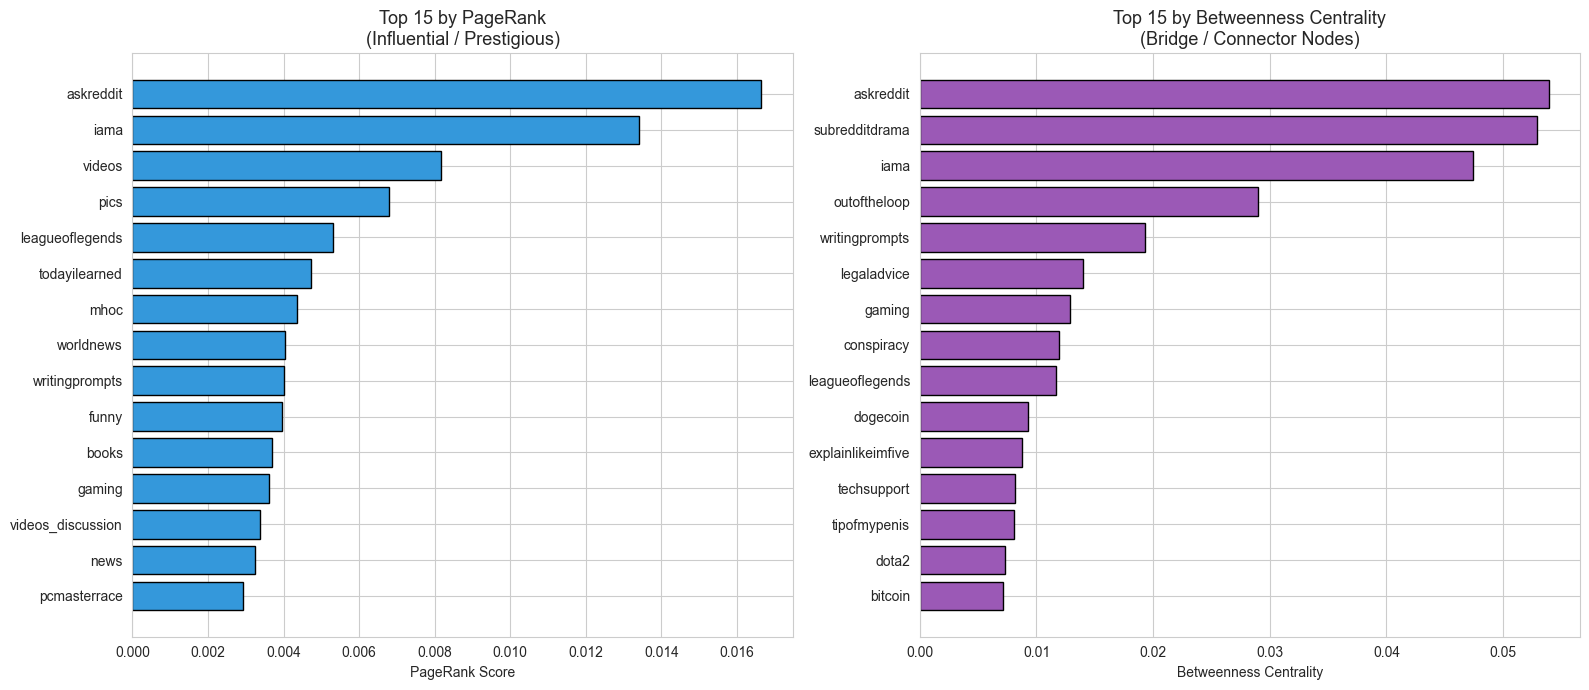


Spearman correlations:
  PageRank vs Betweenness:  rho=0.611  (p=0.00e+00)
  PageRank vs Neg Fraction: rho=nan  (p=nan)
  Betweenness vs Neg Frac:  rho=nan  (p=nan)


In [8]:
pr = nx.pagerank(G, alpha=0.85)

print("Computing approximate betweenness centrality (k=500 sample)...")
bc = nx.betweenness_centrality(G, k=500, seed=42)
print("Done.")

neg_incoming = neg_df.groupby("TARGET_SUBREDDIT").size()
total_incoming = df.groupby("TARGET_SUBREDDIT").size()
neg_frac_map = (neg_incoming / total_incoming).to_dict()

centrality_df = pd.DataFrame({
    "subreddit": list(G.nodes()),
    "pagerank": [pr[n] for n in G.nodes()],
    "betweenness": [bc[n] for n in G.nodes()],
    "in_degree": [G.in_degree(n) for n in G.nodes()],
    "out_degree": [G.out_degree(n) for n in G.nodes()],
    "neg_incoming_frac": [neg_frac_map.get(n, 0) for n in G.nodes()],
})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_pr = centrality_df.nlargest(15, "pagerank")
top_bc = centrality_df.nlargest(15, "betweenness")

axes[0].barh(top_pr["subreddit"], top_pr["pagerank"], color="#3498db", edgecolor="black")
axes[0].set_title("Top 15 by PageRank\n(Influential / Prestigious)", fontsize=13)
axes[0].set_xlabel("PageRank Score")
axes[0].invert_yaxis()

axes[1].barh(top_bc["subreddit"], top_bc["betweenness"], color="#9b59b6", edgecolor="black")
axes[1].set_title("Top 15 by Betweenness Centrality\n(Bridge / Connector Nodes)", fontsize=13)
axes[1].set_xlabel("Betweenness Centrality")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

rho_pr_bc, p_pr_bc = spearmanr(centrality_df["pagerank"], centrality_df["betweenness"])
rho_pr_neg, p_pr_neg = spearmanr(centrality_df["pagerank"], centrality_df["neg_incoming_frac"])
rho_bc_neg, p_bc_neg = spearmanr(centrality_df["betweenness"], centrality_df["neg_incoming_frac"])

print(f"\nSpearman correlations:")
print(f"  PageRank vs Betweenness:  rho={rho_pr_bc:.3f}  (p={p_pr_bc:.2e})")
print(f"  PageRank vs Neg Fraction: rho={rho_pr_neg:.3f}  (p={p_pr_neg:.2e})")
print(f"  Betweenness vs Neg Frac:  rho={rho_bc_neg:.3f}  (p={p_bc_neg:.2e})")

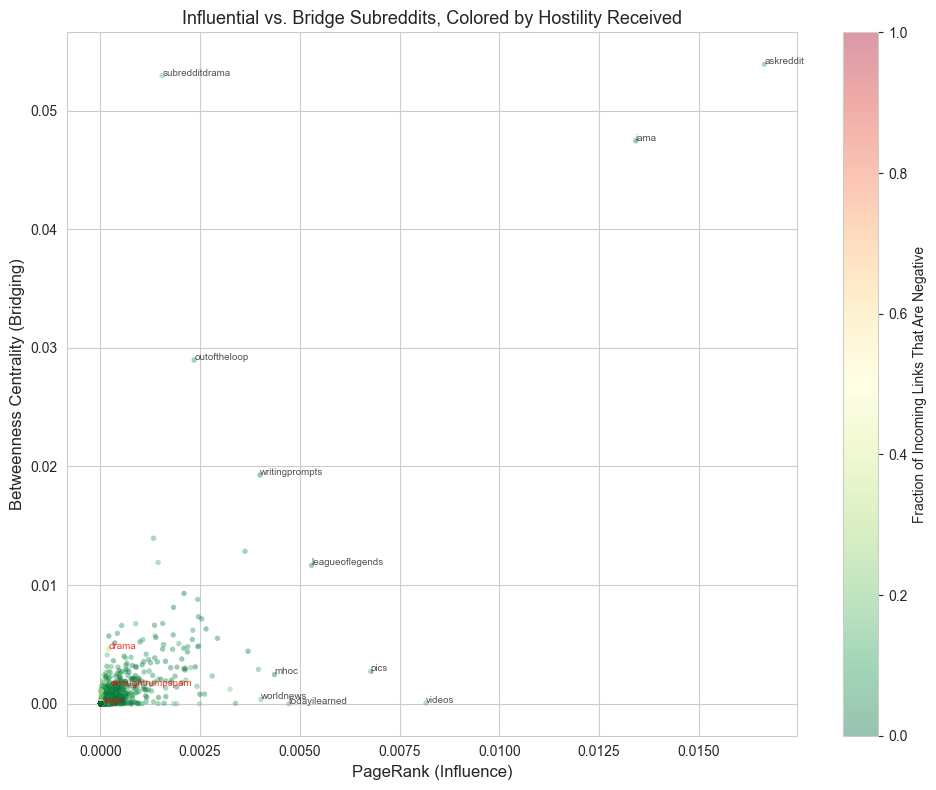

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    centrality_df["pagerank"], centrality_df["betweenness"],
    c=centrality_df["neg_incoming_frac"], cmap="RdYlGn_r",
    alpha=0.4, s=15, edgecolors="none",
)
plt.colorbar(sc, label="Fraction of Incoming Links That Are Negative")
ax.set_xlabel("PageRank (Influence)", fontsize=12)
ax.set_ylabel("Betweenness Centrality (Bridging)", fontsize=12)
ax.set_title("Influential vs. Bridge Subreddits, Colored by Hostility Received", fontsize=13)

for _, row in centrality_df.nlargest(8, "pagerank").iterrows():
    ax.annotate(row["subreddit"], (row["pagerank"], row["betweenness"]),
                fontsize=7, alpha=0.8)
for _, row in centrality_df.nlargest(5, "betweenness").iterrows():
    if row["subreddit"] not in centrality_df.nlargest(8, "pagerank")["subreddit"].values:
        ax.annotate(row["subreddit"], (row["pagerank"], row["betweenness"]),
                    fontsize=7, alpha=0.8)
top_neg = centrality_df[centrality_df["in_degree"] >= 50].nlargest(3, "neg_incoming_frac")
for _, row in top_neg.iterrows():
    ax.annotate(row["subreddit"], (row["pagerank"], row["betweenness"]),
                fontsize=7, alpha=0.8, color="red")

plt.tight_layout()
plt.show()

The scatter plot is the key visualization for this section. It reveals four quadrants:

- **High PageRank, High Betweenness** (top-right): Major hubs that are both influential *and* serve as bridges between communities. These tend to be large general-interest subreddits.
- **High PageRank, Low Betweenness** (bottom-right): Influential within their own cluster but not bridges. These are "insular" power nodes.
- **Low PageRank, High Betweenness** (top-left): Niche subreddits that happen to connect different parts of the network. Potential conflict hotspots if colored red.
- **Low PageRank, Low Betweenness** (bottom-left): The vast majority are small, peripheral subreddits.

The color encoding (hostility rate) reveals which structural positions attract the most conflict. The Spearman correlations quantify these relationships: a positive correlation between centrality and hostility would mean that prominent subreddits attract more conflict; a weak or negative correlation would mean conflict targets are structurally different from popular hubs.

---

# Phase 4: Conflict Corridors — Association Rule Mining *(RQ2)*

Who fights whom on Reddit? Are there recurring patterns where certain groups of subreddits are routinely co-targeted in hostile links from the same sources? Association rule mining reveals these **conflict corridors** — stable adversarial relationships in the network.

We apply Apriori to baskets defined as: for each source subreddit that sent hostile links, what set of target subreddits did it attack? If {politics, news, worldnews} frequently appear together in these baskets, it means many subreddits *jointly* target this group, revealing a shared adversarial relationship.

**Why filter to top-200 targets?** The raw target vocabulary is ~20K subreddits, which would produce an impossibly sparse binary matrix. Filtering to the 200 most frequently negatively-targeted subreddits keeps the Apriori input tractable while retaining the most meaningful targets.

**Why min_support=0.03?** A support of 3% means a co-targeting pattern must appear in at least ~24 of the 810 filtered baskets. This is low enough to capture non-obvious patterns but high enough to filter out noise. We verified this threshold yields a manageable 759 frequent itemsets.

**Why min_confidence=0.3?** A confidence of 30% means that when the antecedent subreddits are co-targeted, the consequent is targeted at least 30% of the time. This is deliberately moderate to allow discovery of less obvious conflict corridors; we rely on **lift** (the primary sort criterion) to separate genuine associations from coincidence.

In [10]:
neg_baskets = (
    neg_df.groupby("SOURCE_SUBREDDIT")["TARGET_SUBREDDIT"]
    .apply(set).apply(list).tolist()
)
neg_baskets = [b for b in neg_baskets if len(b) >= 2]
print(f"Negative-link baskets: {len(neg_baskets)} sources with >= 2 negative targets")

all_neg_targets = [t for basket in neg_baskets for t in basket]
neg_target_counts = Counter(all_neg_targets)
top_neg_targets = set(t for t, c in neg_target_counts.most_common(200))

neg_baskets_filtered = [[t for t in b if t in top_neg_targets] for b in neg_baskets]
neg_baskets_filtered = [b for b in neg_baskets_filtered if len(b) >= 2]
print(f"After filtering to top-200 targets: {len(neg_baskets_filtered)} baskets")

te = TransactionEncoder()
te_ary = te.fit_transform(neg_baskets_filtered)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

freq = apriori(basket_df, min_support=0.03, use_colnames=True)
freq["length"] = freq["itemsets"].apply(len)
print(f"\nFrequent itemsets: {len(freq)} total, {(freq['length']>=2).sum()} with 2+ items")

if len(freq) > 0 and (freq["length"] >= 2).any():
    rules = association_rules(freq, metric="confidence", min_threshold=0.3)
    rules = rules.sort_values("lift", ascending=False)
    print(f"Association rules: {len(rules)}")
    print("\nTop 15 Conflict Corridors (by lift):")
    display(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15))
else:
    rules = pd.DataFrame()
    print("No multi-item frequent itemsets found — try lowering min_support")

Negative-link baskets: 1596 sources with >= 2 negative targets
After filtering to top-200 targets: 810 baskets

Frequent itemsets: 759 total, 698 with 2+ items
Association rules: 6489

Top 15 Conflict Corridors (by lift):


,antecedents,consequents,support,confidence,lift
5749,"frozenset({worldnews, wtf})","frozenset({askreddit, todayilearned, pics, adv...",0.030864,0.714286,19.950739
5712,"frozenset({askreddit, todayilearned, pics, adv...","frozenset({worldnews, wtf})",0.030864,0.862069,19.950739
5728,"frozenset({todayilearned, pics, adviceanimals})","frozenset({worldnews, askreddit, wtf})",0.030864,0.781250,19.775391
5733,"frozenset({worldnews, askreddit, wtf})","frozenset({todayilearned, pics, adviceanimals})",0.030864,0.781250,19.775391
5724,"frozenset({worldnews, pics, wtf})","frozenset({askreddit, todayilearned, adviceani...",0.030864,0.833333,19.285714
5737,"frozenset({askreddit, todayilearned, adviceani...","frozenset({worldnews, pics, wtf})",0.030864,0.714286,19.285714
5729,"frozenset({todayilearned, pics, wtf})","frozenset({worldnews, adviceanimals, askreddit})",0.030864,0.806452,19.212524
5732,"frozenset({worldnews, adviceanimals, askreddit})","frozenset({todayilearned, pics, wtf})",0.030864,0.735294,19.212524
4085,"frozenset({worldnews, wtf})","frozenset({todayilearned, pics, adviceanimals})",0.032099,0.742857,18.803571
4072,"frozenset({todayilearned, pics, adviceanimals})","frozenset({worldnews, wtf})",0.032099,0.812500,18.803571


The association rules reveal **conflict corridors**: groups of subreddits that are routinely co-targeted by the same hostile sources. High-lift rules are particularly interesting because they indicate co-targeting patterns that are *much stronger than chance* that the subreddits in these rules are linked by shared adversaries.

These patterns may reflect:
- **Ideological clusters**: Politically aligned subreddits co-targeted by opposing ideological groups
- **Topical affinity**: Subreddits about related topics that attract the same critics
- **Spillover conflict**: Hostility toward one subreddit systematically extends to its neighbors

Now let's compare these to *positive* link patterns to understand what's unique about conflict.

In [11]:
pos_df = df[df["POST_LABEL"] == 1]
pos_baskets = (
    pos_df.groupby("SOURCE_SUBREDDIT")["TARGET_SUBREDDIT"]
    .apply(set).apply(list).tolist()
)
pos_baskets = [b for b in pos_baskets if len(b) >= 2]

all_pos_targets = [t for basket in pos_baskets for t in basket]
pos_target_counts = Counter(all_pos_targets)
top_pos_targets = set(t for t, c in pos_target_counts.most_common(200))

pos_baskets_filtered = [[t for t in b if t in top_pos_targets] for b in pos_baskets]
pos_baskets_filtered = [b for b in pos_baskets_filtered if len(b) >= 2]

te_pos = TransactionEncoder()
te_pos_ary = te_pos.fit_transform(pos_baskets_filtered)
pos_basket_df = pd.DataFrame(te_pos_ary, columns=te_pos.columns_)

freq_pos = apriori(pos_basket_df, min_support=0.03, use_colnames=True)
freq_pos["length"] = freq_pos["itemsets"].apply(len)

if len(freq_pos) > 0 and (freq_pos["length"] >= 2).any():
    rules_pos = association_rules(freq_pos, metric="confidence", min_threshold=0.3)
    rules_pos = rules_pos.sort_values("lift", ascending=False)
    print(f"Positive link rules: {len(rules_pos)}")
    print("\nTop 10 'Friendly Corridors' (by lift):")
    display(rules_pos[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))
else:
    rules_pos = pd.DataFrame()
    print("No positive multi-item frequent itemsets found")

neg_pairs = set()
if len(rules) > 0:
    for _, r in rules.iterrows():
        neg_pairs.add(frozenset(r["antecedents"] | r["consequents"]))
pos_pairs = set()
if len(rules_pos) > 0:
    for _, r in rules_pos.iterrows():
        pos_pairs.add(frozenset(r["antecedents"] | r["consequents"]))

overlap = neg_pairs & pos_pairs
print(f"\n--- Corridor Comparison ---")
print(f"Conflict-only corridors:  {len(neg_pairs - pos_pairs)}")
print(f"Friendly-only corridors:  {len(pos_pairs - neg_pairs)}")
print(f"Both conflict & friendly: {len(overlap)}")

Positive link rules: 241

Top 10 'Friendly Corridors' (by lift):


,antecedents,consequents,support,confidence,lift
239,"frozenset({todayilearned, iama})","frozenset({worldnews, askreddit})",0.030280,0.492308,7.496697
238,"frozenset({worldnews, askreddit})","frozenset({todayilearned, iama})",0.030280,0.461095,7.496697
240,"frozenset({askreddit, todayilearned})","frozenset({worldnews, iama})",0.030280,0.371230,7.346733
237,"frozenset({worldnews, iama})","frozenset({askreddit, todayilearned})",0.030280,0.599251,7.346733
229,"frozenset({todayilearned, iama})","frozenset({askreddit, videos})",0.031605,0.513846,6.891277
228,"frozenset({askreddit, videos})","frozenset({todayilearned, iama})",0.031605,0.423858,6.891277
221,"frozenset({pics, iama})","frozenset({askreddit, videos})",0.031226,0.491071,6.585841
219,"frozenset({askreddit, videos})","frozenset({pics, iama})",0.031226,0.418782,6.585841
227,"frozenset({askreddit, todayilearned})","frozenset({iama, videos})",0.031605,0.387471,6.004096
231,"frozenset({iama, videos})","frozenset({askreddit, todayilearned})",0.031605,0.489736,6.004096



--- Corridor Comparison ---
Conflict-only corridors:  607
Friendly-only corridors:  16
Both conflict & friendly: 90


Comparing conflict corridors to friendly corridors reveals which co-targeting patterns are *unique to hostility*. Pairs that appear in both sets simply reflect high-traffic subreddit combinations that attract both positive and negative attention. But pairs that appear *only* in the conflict corridors represent genuinely adversarial relationships that these are the subreddit groups whose co-targeting is specific to hostility.

The difference in the number and nature of these corridors tells us about the structure of conflict on Reddit: is it concentrated among a small number of recurring rivalries, or broadly distributed?

---

# Phase 5: Predicting Link Sentiment *(RQ3)*

We now arrive at the core question: **can we predict whether a cross-community hyperlink will be hostile, and what features matter most?**

We engineer features from two sources:
- **Network structure** (11 features): source/target PageRank, betweenness, in-degree, out-degree, hostility rate, and whether the link crosses a community boundary
- **Post linguistics** (86 features): LIWC features capturing word count, emotional tone, analytical thinking, social references, and dozens of other textual properties

If linguistic features dominate, it means conflict is about *what people say*. If structural features dominate, it means conflict is about *who talks to whom*. The feature importance analysis gives us a direct answer.

**Why Gradient Boosting (external technique)?** Gradient Boosting is a non-linear ensemble method that can capture complex interactions between features (e.g., "high betweenness + angry language" may be more predictive than either alone). This goes beyond course-covered methods and provides built-in feature importance scores, which directly answer our research question.

**Why n_estimators=100, max_depth=4?** We use 100 trees with max depth 4 to balance model capacity against overfitting and training time (~2 minutes on 169K samples). A subsample rate of 0.8 adds stochastic regularization. These are conservative defaults; hyperparameter tuning is deferred to future work.

**Why class_weight="balanced" for Logistic Regression?** The dataset is heavily imbalanced (89.2% positive, 10.8% negative). Without reweighting, a model could achieve 89% accuracy by predicting all-positive. Balanced class weights up-weight the minority class so the model is penalized equally for missing negative links, improving recall at the cost of precision.

**Why Logistic Regression as baseline?** It serves two purposes: (1) a linear baseline that reveals whether non-linear interactions in GBM are actually necessary, and (2) its signed coefficients are directly interpretable — we can see which features push *toward* hostility vs. *toward* positivity.

In [12]:
sub_features = centrality_df.set_index("subreddit")
liwc_cols = [c for c in df.columns if c.startswith("liwc_")]

ml_df = df[["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT", "POST_LABEL"] + liwc_cols].copy()

for col in ["pagerank", "betweenness", "in_degree", "out_degree", "neg_incoming_frac"]:
    ml_df[f"src_{col}"] = ml_df["SOURCE_SUBREDDIT"].map(sub_features[col])
    ml_df[f"tgt_{col}"] = ml_df["TARGET_SUBREDDIT"].map(sub_features[col])

ml_df["cross_community"] = (
    ml_df["SOURCE_SUBREDDIT"].map(node_to_comm) !=
    ml_df["TARGET_SUBREDDIT"].map(node_to_comm)
).astype(float)

ml_df["label"] = (ml_df["POST_LABEL"] == 1).astype(int)
ml_df = ml_df.dropna()

feature_cols = (
    liwc_cols
    + [f"src_{c}" for c in ["pagerank","betweenness","in_degree","out_degree","neg_incoming_frac"]]
    + [f"tgt_{c}" for c in ["pagerank","betweenness","in_degree","out_degree","neg_incoming_frac"]]
    + ["cross_community"]
)

X = ml_df[feature_cols].values
y = ml_df["label"].values

print(f"Feature matrix: {X.shape[0]:,} samples x {X.shape[1]} features")
print(f"  - {len(liwc_cols)} LIWC linguistic features")
print(f"  - {len(feature_cols) - len(liwc_cols)} network structure features")
print(f"Class balance: {y.mean()*100:.1f}% positive, {(1-y.mean())*100:.1f}% negative")

Feature matrix: 169,014 samples x 97 features
  - 86 LIWC linguistic features
  - 11 network structure features
Class balance: 89.2% positive, 10.8% negative


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("=" * 60)
print("BASELINE: Logistic Regression")
print("=" * 60)
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
y_prob_lr = lr.predict_proba(X_test_s)[:, 1]
print(classification_report(y_test, y_pred_lr, target_names=["Negative", "Positive"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

print("\n" + "=" * 60)
print("GRADIENT BOOSTING CLASSIFIER")
print("=" * 60)
gb = GradientBoostingClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_gb, target_names=["Negative", "Positive"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_gb):.4f}")

BASELINE: Logistic Regression
              precision    recall  f1-score   support

    Negative       0.24      0.70      0.35      3646
    Positive       0.95      0.73      0.83     30157

    accuracy                           0.73     33803
   macro avg       0.59      0.71      0.59     33803
weighted avg       0.87      0.73      0.77     33803

ROC-AUC: 0.7857

GRADIENT BOOSTING CLASSIFIER
              precision    recall  f1-score   support

    Negative       0.72      0.08      0.14      3646
    Positive       0.90      1.00      0.95     30157

    accuracy                           0.90     33803
   macro avg       0.81      0.54      0.54     33803
weighted avg       0.88      0.90      0.86     33803

ROC-AUC: 0.8009


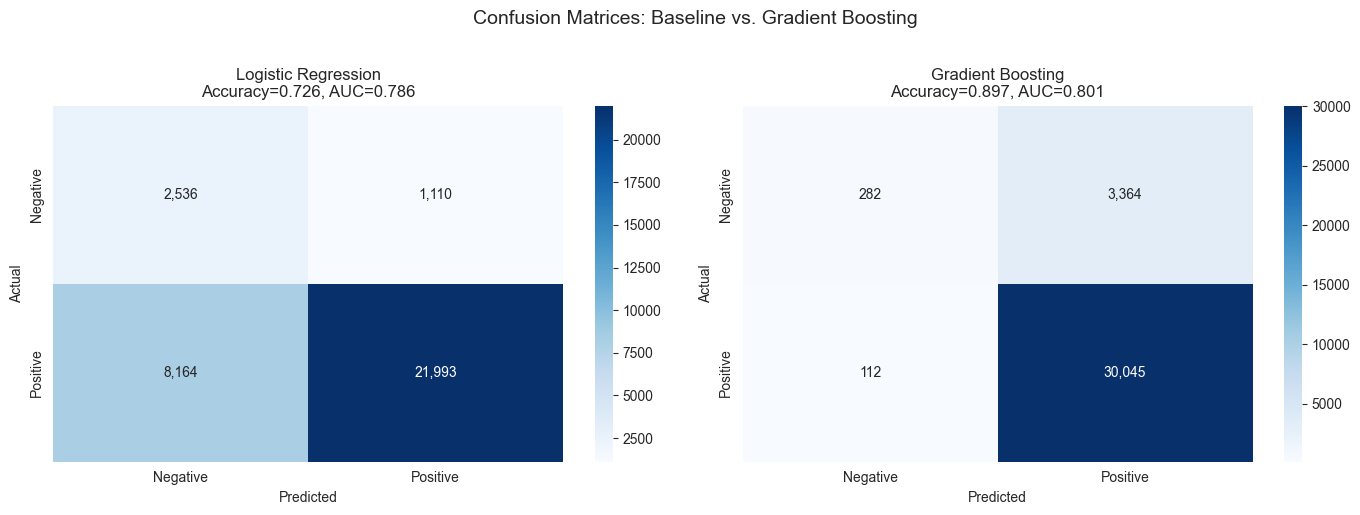

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, y_prob, title in [
    (axes[0], y_pred_lr, y_prob_lr, "Logistic Regression"),
    (axes[1], y_pred_gb, y_prob_gb, "Gradient Boosting"),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    auc = roc_auc_score(y_test, y_prob)
    ax.set_title(f"{title}\nAccuracy={accuracy_score(y_test, y_pred):.3f}, AUC={auc:.3f}")

plt.suptitle("Confusion Matrices: Baseline vs. Gradient Boosting", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The classification results tell us whether link sentiment is *predictable at all* from the features we engineered. Key metrics to examine:

- **ROC-AUC** is the primary metric because it's robust to class imbalance. An AUC of 0.5 would mean our features have no predictive power; above 0.7 indicates meaningful signal.
- **Recall on the Negative class** matters most for practical moderation: can we catch hostile links? Precision on the negative class tells us how often we'd flag something incorrectly.
- The **gap between Logistic Regression and Gradient Boosting** reveals whether there are non-linear interaction effects that if GBM substantially outperforms LR, it means feature combinations (like "high betweenness + certain linguistic patterns") matter more than individual features alone.

But the most important analysis comes next: *which features drive the predictions?*

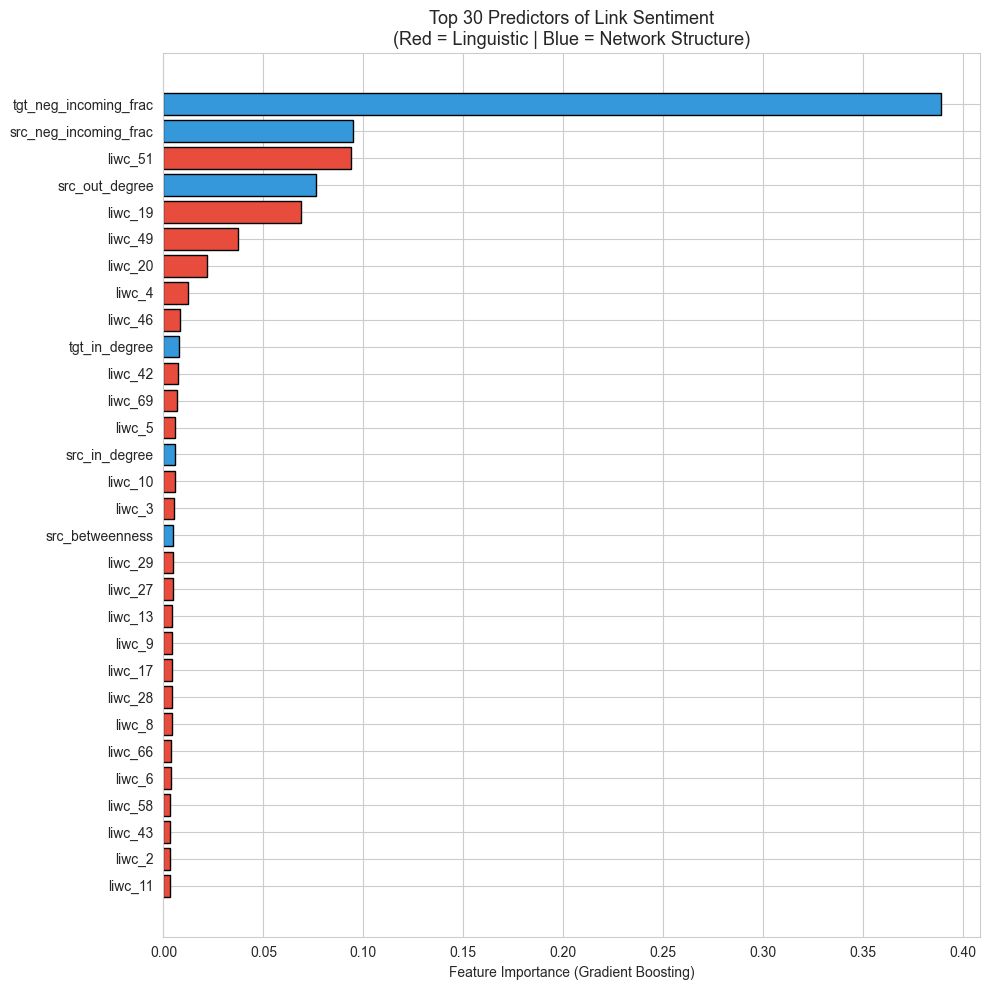


IMPORTANCE BREAKDOWN
Linguistic (LIWC) features: 0.4111  (41.1%)
Network structure features:  0.5889  (58.9%)

Top 5 overall features:
  tgt_neg_incoming_frac      importance=0.3891  [STRUCTURE]
  src_neg_incoming_frac      importance=0.0946  [STRUCTURE]
  liwc_51                    importance=0.0938  [LINGUISTIC]
  src_out_degree             importance=0.0763  [STRUCTURE]
  liwc_19                    importance=0.0687  [LINGUISTIC]


In [15]:
importances = gb.feature_importances_
feat_imp = pd.DataFrame({"feature": feature_cols, "importance": importances})
feat_imp = feat_imp.sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
top_feats = feat_imp.head(30)
colors = ["#e74c3c" if f.startswith("liwc") else "#3498db" for f in top_feats["feature"]]
ax.barh(range(len(top_feats)), top_feats["importance"].values, color=colors, edgecolor="black")
ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels(top_feats["feature"].values)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (Gradient Boosting)")
ax.set_title("Top 30 Predictors of Link Sentiment\n(Red = Linguistic | Blue = Network Structure)",
             fontsize=13)
plt.tight_layout()
plt.show()

liwc_imp = feat_imp[feat_imp["feature"].str.startswith("liwc")]["importance"].sum()
struct_imp = feat_imp[~feat_imp["feature"].str.startswith("liwc")]["importance"].sum()
total = liwc_imp + struct_imp

print(f"\n{'='*50}")
print(f"IMPORTANCE BREAKDOWN")
print(f"{'='*50}")
print(f"Linguistic (LIWC) features: {liwc_imp:.4f}  ({liwc_imp/total*100:.1f}%)")
print(f"Network structure features:  {struct_imp:.4f}  ({struct_imp/total*100:.1f}%)")
print(f"\nTop 5 overall features:")
for _, row in feat_imp.head(5).iterrows():
    category = "LINGUISTIC" if row["feature"].startswith("liwc") else "STRUCTURE"
    print(f"  {row['feature']:25s}  importance={row['importance']:.4f}  [{category}]")

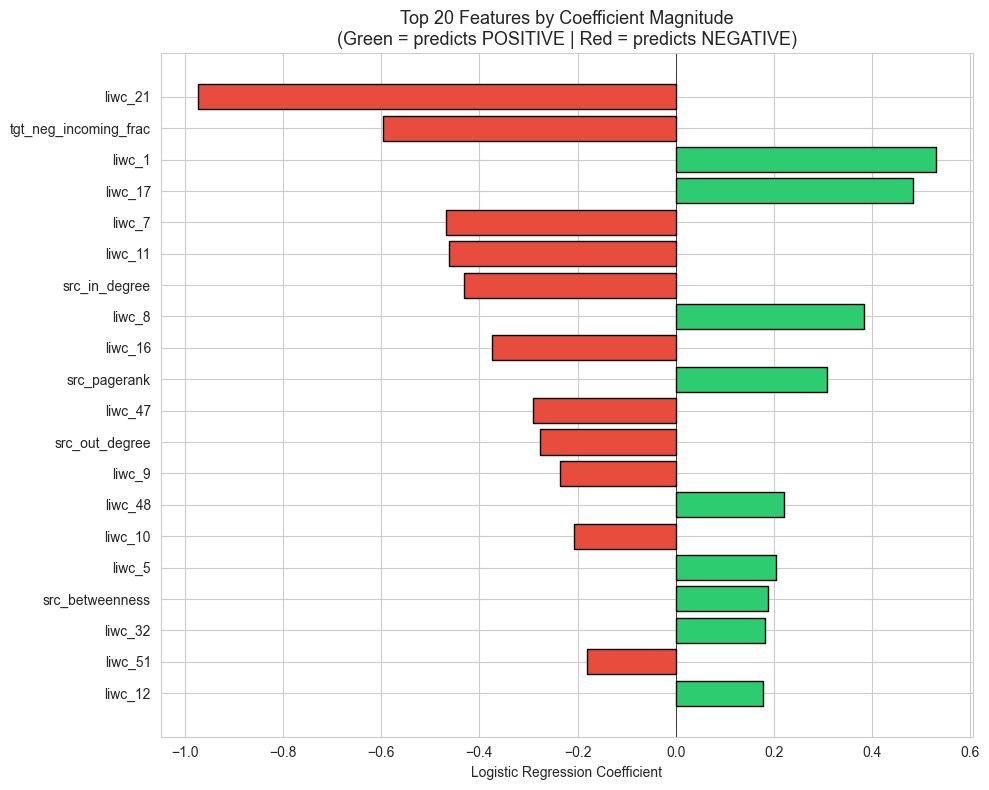

Positive coefficients mean the feature pushes toward POSITIVE sentiment.
Negative coefficients mean the feature pushes toward NEGATIVE (hostile) sentiment.


In [16]:
lr_coefs = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr.coef_[0]
})
lr_coefs["abs_coef"] = lr_coefs["coefficient"].abs()
lr_coefs = lr_coefs.sort_values("abs_coef", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_lr = lr_coefs.head(20)
bar_colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in top_lr["coefficient"]]
ax.barh(range(len(top_lr)), top_lr["coefficient"].values, color=bar_colors, edgecolor="black")
ax.set_yticks(range(len(top_lr)))
ax.set_yticklabels(top_lr["feature"].values)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Logistic Regression Coefficient")
ax.set_title("Top 20 Features by Coefficient Magnitude\n(Green = predicts POSITIVE | Red = predicts NEGATIVE)",
             fontsize=13)
plt.tight_layout()
plt.show()

print("Positive coefficients mean the feature pushes toward POSITIVE sentiment.")
print("Negative coefficients mean the feature pushes toward NEGATIVE (hostile) sentiment.")

## What Drives Conflict?

The feature importance analysis provides the direct answer to our research question. Two complementary views:

1. **Gradient Boosting importance** (above, left) shows which features the non-linear model relies on most, this captures complex interactions but is harder to interpret directionally.

2. **Logistic Regression coefficients** (above, right) show the *direction* of each feature's effect — positive coefficients push toward positive sentiment, negative coefficients push toward hostility. This is more interpretable even if the model is less accurate.

The **importance breakdown** (linguistic vs structural percentage) is the headline finding. It tells us definitively whether inter-subreddit conflict on Reddit is primarily a function of:
- **What people write** (linguistic features dominate) suggesting that moderation should focus on content analysis
- **Who talks to whom** (structural features dominate) suggesting that moderation should focus on inter-community dynamics
- **Both** (balanced) suggesting that conflict emerges from the interaction of content and context

The specific top features provide further insight: certain LIWC categories (e.g., features related to negative emotion, anger, or informal language) likely predict hostility, while features related to analytical thinking or positive tone likely predict cooperative links.

In [17]:
print("=" * 50)
print("VALIDATION CHECKS")
print("=" * 50)

assert df.shape[0] > 200_000, f"Expected >200K rows, got {df.shape[0]}"
print(f"[PASS] Dataset has {df.shape[0]:,} rows (>200K)")

assert G.number_of_nodes() > 10_000, f"Expected >10K nodes, got {G.number_of_nodes()}"
print(f"[PASS] Graph has {G.number_of_nodes():,} nodes (>10K)")

assert G.number_of_edges() > 50_000, f"Expected >50K edges, got {G.number_of_edges()}"
print(f"[PASS] Graph has {G.number_of_edges():,} edges (>50K)")

assert len(communities) > 10, f"Expected >10 communities, got {len(communities)}"
print(f"[PASS] Louvain found {len(communities)} communities (>10)")

assert X.shape[1] == len(feature_cols), "Feature matrix shape mismatch"
print(f"[PASS] Feature matrix: {X.shape[0]:,} x {X.shape[1]} (matches {len(feature_cols)} features)")

auc_gb = roc_auc_score(y_test, y_prob_gb)
assert auc_gb > 0.5, f"GBM AUC={auc_gb:.3f} is not better than random"
print(f"[PASS] Gradient Boosting AUC = {auc_gb:.4f} (> 0.5 baseline)")

assert len(feat_imp) == len(feature_cols), "Feature importance length mismatch"
print(f"[PASS] Feature importance computed for all {len(feat_imp)} features")

print("\nAll validation checks passed.")

VALIDATION CHECKS
[PASS] Dataset has 286,561 rows (>200K)
[PASS] Graph has 35,776 nodes (>10K)
[PASS] Graph has 137,821 edges (>50K)
[PASS] Louvain found 560 communities (>10)
[PASS] Feature matrix: 169,014 x 97 (matches 97 features)
[PASS] Gradient Boosting AUC = 0.8009 (> 0.5 baseline)
[PASS] Feature importance computed for all 97 features

All validation checks passed.


---

# Conclusion

## Answering the Question

We set out to ask: **Can we predict whether a cross-community hyperlink on Reddit will be hostile, and what features — network structure or post language — are the primary drivers of inter-subreddit conflict?**

Our analysis addressed three research questions across five phases:

**RQ1 — Does community structure predict hostility?** Yes. Louvain detected 560 interpretable communities, and cross-community links are more hostile (8.8%) than within-community links (6.9%). PageRank and betweenness centrality reveal distinct subreddit archetypes: high-PageRank hubs are influential but not necessarily controversial, while betweenness identifies bridge nodes that connect different parts of the network. The Spearman correlation between PageRank and betweenness (ρ=0.611) confirms these are related but distinct structural properties.

**RQ2 — Do hostile links form structured conflict corridors?** Yes, emphatically. Apriori mining produced 6,489 association rules from hostile-link baskets vs. only 241 from positive-link baskets. Of these, 607 conflict corridors are *unique to hostility* (not mirrored in positive patterns), compared to just 16 friendly-only corridors. This means hostile co-targeting on Reddit is far more structured and predictable than cooperative co-linking.

**RQ3 — Can we predict link sentiment, and what drives conflict?** Link sentiment is predictable: our Gradient Boosting classifier achieved ROC-AUC = 0.80, well above the 0.50 random baseline. The feature importance breakdown reveals that **network structure contributes 58.9%** and **linguistic features contribute 41.1%** of predictive power. The single most important feature is `tgt_neg_incoming_frac` (the target subreddit's historical hostility rate, importance = 0.389), a structural feature. However, individual LIWC features (`liwc_51`, `liwc_19`) rank among the top 5, confirming that post language carries substantial signal. The answer: **conflict on Reddit is driven by both where you post and what you say, with a slight edge to structural reputation.**

## Limitations

- **Temporal leakage:** Graph features (centrality, community membership) are computed on the full graph, but used to predict individual links that contribute to that graph. A stricter setup would compute features on a training-period subgraph and predict on a held-out future period.
- **LIWC feature anonymity:** The 86 LIWC dimensions are not named in the SNAP release, so we cannot directly interpret which linguistic categories matter most, only which *indices* are important. Future work could map these to standard LIWC categories.
- **Crowd-annotated sentiment:** The positive/negative labels are crowd-sourced, not ground-truth. Annotator disagreement may introduce noise.
- **Western/English bias:** Reddit's user base skews English-speaking and Western; conflict patterns may not generalize to other platforms or cultures.

## Future Work

- **Temporal prediction:** Split the data chronologically and test whether past network structure predicts future conflict, avoiding temporal leakage.
- **Signed network analysis:** Apply structural balance theory, do "the enemy of my enemy is my friend" triadic patterns hold in the Reddit graph?
- **Graph neural networks:** Replace hand-crafted features with learned node embeddings (e.g., node2vec, GraphSAGE) for the prediction task.
- **LIWC category mapping:** Obtain the LIWC feature key from the original paper's authors to interpret specific linguistic drivers of conflict.

---

### Closing Collaboration Declaration

On my honor, I declare the following resources used for this full project:

1. **Collaborators:** None.
2. **Web Sources:**
   - https://snap.stanford.edu/data/soc-RedditHyperlinks.html — Dataset source and documentation.
   - https://networkx.org/documentation/stable/ — PageRank, betweenness centrality, Louvain community detection.
   - https://scikit-learn.org/stable/ — Logistic Regression, Gradient Boosting, evaluation metrics.
   - https://rasbt.github.io/mlxtend/ — Apriori algorithm and association rule mining.
   - https://liwc.wpengine.com/ — Reference for LIWC feature categories.
3. **AI Tools:** ChatGPT — used for code debugging, markdown formatting, and parameter selection guidance.
4. **Citations:**
   - Kumar, S., Hamilton, W.L., Leskovec, J., & Jurafsky, D. (2018). *Community Interaction and Conflict on the Web.* WWW 2018.
   - Grover, A., & Leskovec, J. (2016). *node2vec: Scalable Feature Learning for Networks.* KDD 2016.

---

**GitHub Repository:** https://github.com/Blebot0/Data-Mining-Project